In [10]:
import pandas as pd
import numpy as np

In [11]:
df = pd.read_csv('assets/UCI_Credit_Card.csv')
df.sample(6)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
4276,4277,80000.0,1,2,2,28,0,0,0,0,...,49460.0,50687.0,50288.0,2050.0,1780.0,1800.0,2000.0,2000.0,2000.0,0
9571,9572,270000.0,1,2,1,49,-2,-2,-2,-2,...,-173.0,-173.0,-173.0,0.0,0.0,0.0,0.0,0.0,0.0,0
8132,8133,310000.0,2,2,2,51,-2,-2,-2,-2,...,235.0,0.0,0.0,0.0,0.0,235.0,0.0,0.0,584.0,0
24808,24809,120000.0,1,2,2,36,0,0,2,0,...,17400.0,26087.0,19577.0,3246.0,0.0,7313.0,15000.0,0.0,7000.0,0
5295,5296,520000.0,1,1,2,34,0,0,0,0,...,13178.0,17059.0,17528.0,5014.0,5010.0,13009.0,10035.0,10007.0,5025.0,0
10995,10996,500000.0,2,2,2,27,0,0,0,0,...,16476.0,12534.0,394163.0,5188.0,3417.0,3000.0,1276.0,388071.0,11700.0,0


In [72]:
print('shape: ',df.shape)
print()
print('columns:', df.columns)


shape:  (30000, 25)

columns: Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')


In [22]:
def dfDetails():
    col_details = {
    'LIMIT_BAL': "Total Credit limit assigned to the client",
    
    'PAYx':"""Repayment status "x"months ago, tells if client paid their credit card bill early,
    on time or late. negative means early,0 means on time and positive means late.""",
    
    'BILL_AMTx': """Bill statement amount for month "x" months ago, total amount bank billed the customer that month. values in this column
    is amount that customer owes to the bank""",

    'PAY_AMTx':'How much customer has paid "x" months ago.'
    
}
    return col_details

In [24]:
dfDetails()

{'LIMIT_BAL': 'Total Credit limit assigned to the client',
 'PAYx': 'Repayment status "x"months ago, tells if client paid their credit card bill early,\n    on time or late. negative means early,0 means on time and positive means late.',
 'BILL_AMTx': 'Bill statement amount for month "x" months ago, total amount bank billed the customer that month. values in this column\n    is amount that customer owes to the bank',
 'PAY_AMTx': 'How much customer has paid "x" months ago.'}

## Naive model without any kind of data preprocessing or hyperparameter tuning

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [76]:
# random split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:-1],df.iloc[:,-1],random_state=42,test_size=0.2)


lr = LogisticRegression()
lr.fit(X_train,y_train)
accuracy_score(y_test,lr.predict(X_test))

C:\Users\jawwa\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7811666666666667

### Suspisious...
Why is a naive model giving almost good accuracy... there is some kind of problem here... is there any data leakage?  
**yes there is**  
features that conveys current on going month's information in any sense is basically helping the model, because in many cases the defaulters will have defaulted stats in these features. cuz its not likely for customers to change in just couple of days, (it is possible but very unlikely)
So this is the reason why even a naive algorithm with no data preprociessing is still giving the accuracy of almost 80%.

**Next step** is to remove all these features from which the model is cheating and then see whats going on.


removing PAY_0(about of credit card bill customer payed this month), BILL_AMT1 (total amount the customer has to pay this month) and PAY_AMT1 (how much customer has paid back already)

In [77]:
df = df.drop(['PAY_0','BILL_AMT1','PAY_AMT1'],axis=1)
df.shape

(30000, 22)

In [78]:
# now lets recheck the accuracy by splitting again
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:-1],df.iloc[:,-1],random_state=42,test_size=0.2)

lr = LogisticRegression()
lr.fit(X_train,y_train)
accuracy_score(y_test,lr.predict(X_test))



C:\Users\jawwa\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7811666666666667

Bamn, the accuracy didn't drop it means the algo is genius in cheating... it can still do its thing from the information os past months...

so lets remove a little more of month's data... and keep only three farthest months.



In [79]:
df = df.drop(['PAY_2','PAY_3','BILL_AMT2','BILL_AMT3','PAY_AMT2','PAY_AMT3'],axis=1)
df.shape

X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:-1],df.iloc[:,-1],random_state=42,test_size=0.2)

lr = LogisticRegression()
lr.fit(X_train,y_train)
accuracy_score(y_test,lr.predict(X_test))


C:\Users\jawwa\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7811666666666667

After removing the most obvious leakage features (PAY_0, BILL_AMT1, PAY_AMT1) and the next-closest months (PAY_2, PAY_3, BILL_AMT2, BILL_AMT3, PAY_AMT2, PAY_AMT3), the accuracy of the naive model remained almost the same (~0.78).
This happens because the dataset contains strongly correlated features from older months and demographics. Even though we removed features that directly reveal the target month, these remaining features still carry predictive patterns that the model can exploit.
Additionally, the random train-test split allows the model to see similar patterns from the same population in both train and test sets.
Therefore, the model is still achieving seemingly high accuracy, but this does not represent true predictive performance — the results are inflated due to indirect leakage and random splitting.
To get a realistic evaluation, we need to split the data temporally and only use features that precede the target month.

In [111]:
df.columns


Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_4',
       'PAY_5', 'PAY_6', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT4',
       'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month'],
      dtype='object')

So let's try to do that now

In [4]:
data = df[['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE','PAY_4',
              'PAY_5', 'PAY_6', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6','default.payment.next.month']]
start = int(data.shape[0] - data.shape[0]*0.2)
end = int(data.shape[0] + 1)

test_data = data.iloc[start:end,:]
print('test data shape:' ,test_data.shape)
train_data = data.iloc[0:start,:]
print('train data shape: ',train_data.shape)

test data shape: (6000, 15)
train data shape:  (24000, 15)


I noticed that ID only increases as the data progresses further, which only meant that data in the bottom rows was of the newr customers. so i used that to my advantage and did this, splitted that data based on time.

In [5]:
y_train = train_data['default.payment.next.month']
X_train = train_data.drop('default.payment.next.month',axis=1)

y_test = test_data['default.payment.next.month']
X_test = test_data.drop('default.payment.next.month',axis=1)

In [7]:
X_test.shape


(6000, 14)

In [132]:
lr = LogisticRegression()
lr.fit(X_train,y_train)
accuracy_score(y_test,lr.predict(X_test))

C:\Users\jawwa\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7888333333333334

After removing the obvious leakage features (PAY_0, BILL_AMT1, PAY_AMT1) and splitting the dataset temporally, the accuracy of the Logistic Regression model did not drop and even slightly increased. This is because the remaining features from older months (PAY_4…PAY_6, BILL_AMT4…6, PAY_AMT4…6) are strongly correlated with the next month’s default. Even without the current-month data, the model can still leverage legitimate historical patterns to predict defaults. Therefore, the high accuracy is not due to leakage, but rather reflects the predictive power of past customer behavior.

This right here is real learning happening.no cheating

alright now lets give it a lil bit of precessed data to see its true potential

In [137]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  24000 non-null  float64
 1   SEX        24000 non-null  int64  
 2   EDUCATION  24000 non-null  int64  
 3   MARRIAGE   24000 non-null  int64  
 4   AGE        24000 non-null  int64  
 5   PAY_4      24000 non-null  int64  
 6   PAY_5      24000 non-null  int64  
 7   PAY_6      24000 non-null  int64  
 8   BILL_AMT4  24000 non-null  float64
 9   BILL_AMT5  24000 non-null  float64
 10  BILL_AMT6  24000 non-null  float64
 11  PAY_AMT4   24000 non-null  float64
 12  PAY_AMT5   24000 non-null  float64
 13  PAY_AMT6   24000 non-null  float64
dtypes: float64(7), int64(7)
memory usage: 2.6 MB


In [140]:
y_train.unique()

array([1, 0])

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [12]:
trans = ColumnTransformer([
    ('scale',StandardScaler(),np.arange(0,14))
])
X_train_trans = trans.fit_transform(X_train)
X_test_trans = trans.transform(X_test)

In [144]:
lr = LogisticRegression()
lr.fit(X_train_trans,y_train)
accuracy_score(y_test,lr.predict(X_test_trans))

# we can see a little bit of increase.

0.7951666666666667

## Time to upgrade to tree models 

In [146]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt

In [147]:
dt  = DecisionTreeClassifier()
dt.fit(X_train_trans,y_train)
accuracy_score(y_test,dt.predict(X_test_trans))

0.703

fully grown decision tree gives 70% test accuracy let's see its training accuracy to confirm its overfitting as well.

In [149]:
accuracy_score(y_train,dt.predict(X_train_trans))

0.9968333333333333

its defnately overfitted. almost 100% accuracy on training data.
lets look at the tree as well.  

(couldn't do that, too much for my laptop to handle)

# Decision Tree tuning

In [191]:
dt  = DecisionTreeClassifier(max_depth=8)
dt.fit(X_train_trans,y_train)
accuracy_score(y_test,dt.predict(X_test_trans))

0.7995

In [192]:
accuracy_score(y_train,dt.predict(X_train_trans))

0.8055

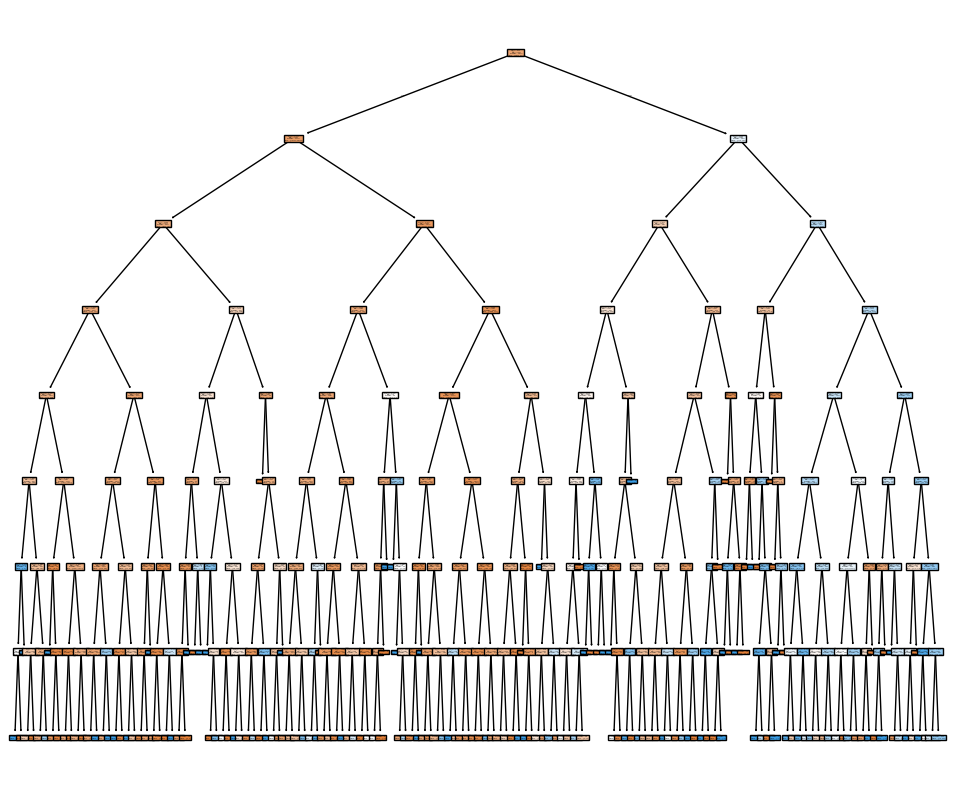

In [194]:
fig = plt.figure(figsize=(12,10))
plot_tree(dt,filled=True)
plt.show()

The unconstrained Decision Tree achieved very high training accuracy but poor test performance, indicating high variance and overfitting. By limiting the tree depth (max_depth = 8), the model’s complexity was reduced, which lowered training accuracy but significantly improved generalization. At this depth, training and testing accuracies became nearly equal, demonstrating a better bias–variance balance where overfitting was controlled at the cost of slightly increased bias.

# RandomForest

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
rf = RandomForestClassifier(max_depth=8,n_estimators=500,n_jobs=-1)
rf.fit(X_train,y_train)
accuracy_score(y_test,rf.predict(X_test))

0.806

In [17]:
accuracy_score(y_train,rf.predict(X_train))

0.805625

With the tree depth constrained, both the Decision Tree and Random Forest achieved similar test accuracy. This is expected, as variance was already controlled at the single-tree level. However, Random Forest is inherently more robust because it aggregates predictions from multiple trees trained on different subsets of data and features, leading to improved stability and reduced sensitivity to data splits, even if this is not reflected as a higher accuracy on a single evaluation.

In [39]:
rf.feature_importances_.reshape(1,14)

array([[0.094042  , 0.00594331, 0.0130044 , 0.0091245 , 0.03787513,
        0.20521469, 0.17676726, 0.12732759, 0.05725438, 0.05410266,
        0.05072267, 0.05978396, 0.05165137, 0.05718607]])

In [35]:
rf.feature_names_in_

array(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_4',
       'PAY_5', 'PAY_6', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'], dtype=object)

<Axes: >

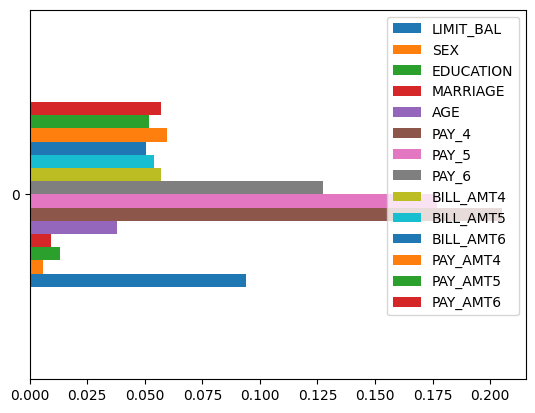

In [45]:
fet = pd.DataFrame(data=list(rf.feature_importances_.reshape(1,14)),columns=list(rf.feature_names_in_))
fet.plot(kind='barh')

<Axes: xlabel='0', ylabel='None'>

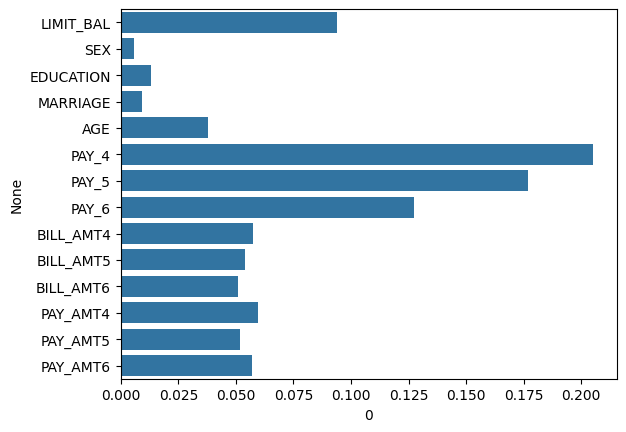

In [53]:
import seaborn as sns

sns.barplot(x=fet.iloc[-1,:],y=fet.columns)

# **Summary**  


- Built a naive baseline model that showed suspiciously high accuracy, prompting further investigation.
- Identified data leakage caused by features containing current-month information that indirectly revealed the target.
- Removed leakage-prone features and adopted a time-aware split, leading to more realistic model evaluation.
- Logistic Regression served as a stable linear baseline, reaching its best performance after scaling.
- An unconstrained Decision Tree heavily overfit the data, demonstrating high variance (very high train accuracy, low test accuracy).
- Limiting tree depth reduced overfitting and achieved a better bias–variance balance, with similar train and test performance.
- Random Forest achieved comparable accuracy to the constrained tree, which is expected once variance is controlled.
- The main advantage of Random Forest lies in improved stability and robustness across different data splits rather than higher accuracy on a single split.
- Overall, the project emphasizes that accuracy alone is not sufficient and that understanding data leakage, validation strategy, and model behavior is crucial in real-world machine learning.
